In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, ExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.plots import render_break_even_dashboard, render_comparative_statics_dashboard, generate_heatmap_from_df, \
    generate_linear_regression_from_lists, generate_histogram_from_array
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense

In [10]:
cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = ExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
advertising_efficiency_model = AdvertisingEfficiencyModel()
free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()
roi_model = RoiModel()

advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=6.8, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
cpa = CostPerAcquisition(min_value=12, max_value=36)
expense = Expense(0)

In [11]:
variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.DEAL_ORDERS: orders,
             variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.COST_ADVERTISING: advertising_budget,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.COST_CPA: cpa,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

expected_result = evaluate_expected_scenario(variables=variables, model_pipeline=[advertising_efficiency_model, cogs_model,
                                                                revenue_model, cost_model, expense_model,
                                                                depreciation_model, net_income_model,
                                                                capital_expenditure_model, profit_model])
print(expected_result[variable_names.PROFIT])

1263823.5294117648


In [12]:
expected_result = evaluate_expected_scenario(variables=variables,
                                             model_pipeline=[cogs_model,
                                                             revenue_model, cost_model, advertising_efficiency_model, expense_model,
                                                             depreciation_model, net_income_model,
                                                             capital_expenditure_model, profit_model])
print(expected_result)

# Model topology error below:
# stochastic_bivariate_simulation(
#     variables=variables,
#     independent_target_x=variable_names.PROFIT,
#     dependent_target_y=variable_names.ROI,
#     shuffled_variables=[variable_names.DEAL_ORDERS,
#                         variable_names.DEAL_SELLING_PRICE,
#                         variable_names.DEAL_ITEMS_PER_ORDER],
#     model_pipeline=[cogs_model,
#                     revenue_model, cost_model,
#                     advertising_efficiency_model, expense_model,
#                     depreciation_model, net_income_model,
#                     capital_expenditure_model, profit_model],
#     sample_size=100)

{'PurchasingPrice': 1500.0, 'Orders': 14.705882352941178, 'USDToRMB': 6.8, 'AdvertisingCost': 20000.0, 'ConversionRate': 0.12000000000000001, 'CostPerAcquisition': 24.0, 'SellingPrice': 4500.0, 'ItemsPerOrder': 3.0, 'Cogs': 112500.0, 'Revenue': 2295000.0, 'Cost': 132500.0, 'Expense': 0.0, 'Depreciation': 0, 'NetIncome': 2162500.0, 'CapitalExpenditure': 0, 'Profit': 2162500.0}


In [13]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.PROFIT,
    dependent_target_y=variable_names.ROI,
    shuffled_variables=[variable_names.DEAL_ORDERS,
                        variable_names.DEAL_SELLING_PRICE,
                        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[cogs_model, revenue_model, cost_model, expense_model,
                    depreciation_model, net_income_model,
                    capital_expenditure_model, profit_model, roi_model],
    sample_size=100)

print(linear_trend_summary)

[2234826.468055083, 3196263.016439018, 1579312.6203810673, 1272336.4775366993, 2457557.4675163957, 1606046.60498662, 576836.1977715186, 1604540.4926684324, 1952848.352458751, 3836045.3572935294, 2126665.9811150297, 4191550.609364358, 1403614.8219832908, 1046965.7040444387, 2905556.072018716, 2534608.123613502, 932206.750322069, 2049720.4000939361, 1765962.0466040485, 983877.9406286838, 2289740.1714810454, 1723694.817760013, 1365843.671563562, 1379960.226992347, 2170904.604798644, 3063229.1220529564, 3003957.57092912, 1502702.0817520695, 1478130.5709427763, 2319432.639947697, 2530844.8787252926, 1008226.1489513204, 4368100.751358702, 2249204.0516949813, 2150494.203629556, 2795257.318052352, 2051733.4407951224, 3148799.072546402, 2644654.655645712, 944357.5117108178, 1346395.720942987, 3985674.0854833303, 1864006.6375643753, 2378434.984923215, 2341490.953023958, 3656906.026483295, 2423127.8340554982, 2521021.345916347, 1468659.9984631762, 1893551.0600164079, 4019054.8770005624, 1776556.0

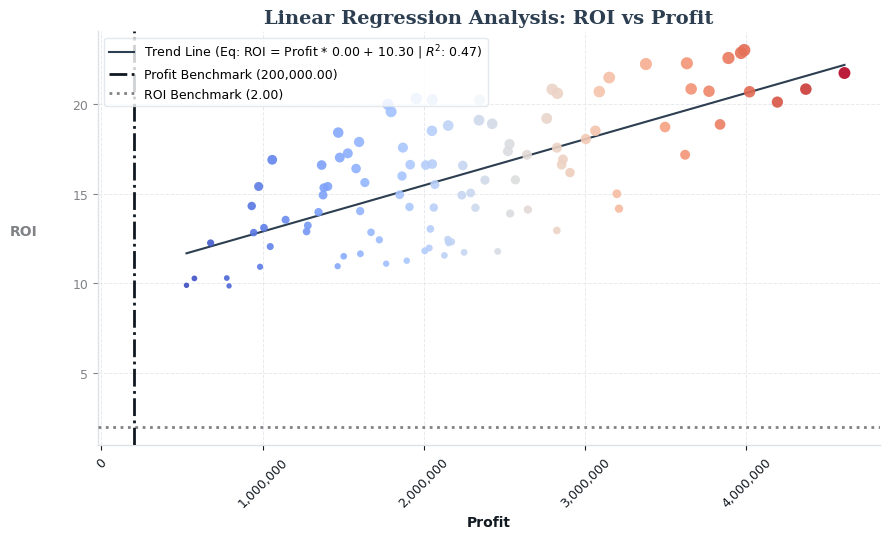

In [14]:
fig, _ = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                               variable_names.PROFIT, variable_names.ROI,
                                               x_benchmark=200000, y_benchmark=2)
plt.show()

In [15]:
variables_2 = {variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
               variable_names.DEAL_SELLING_PRICE: selling_price,
               variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
               variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
               variable_names.COST_ADVERTISING: advertising_budget,
               variable_names.COST_CPA: cpa,
               variable_names.COST_CONVERSION_RATE: conversion_rate,
               variable_names.EXPENSE: expense}

simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables_2,
    independent_target_x=variable_names.COST_ADVERTISING,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[
        variable_names.COST_ADVERTISING,
        variable_names.DEAL_SELLING_PRICE,
        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[advertising_efficiency_model, cogs_model, revenue_model, cost_model,
                    depreciation_model, capital_expenditure_model,
                    net_income_model, profit_model, roi_model],
    sample_size=100)

print(linear_trend_summary)

[22753.678, 20119.5496, 26398.5124, 24364.2466, 14354.1633, 20474.6704, 25033.7574, 19441.8435, 28520.8997, 24886.4412, 11301.4321, 19416.6265, 18934.5119, 28740.836, 21242.9123, 13572.3257, 13842.7895, 12705.9488, 10882.0942, 10970.6732, 16847.9019, 26429.2709, 13635.678, 26640.9271, 18686.6318, 21322.8762, 11370.9163, 11483.0886, 26386.26, 16580.7373, 19199.7426, 19839.7149, 17025.6162, 23990.5751, 23671.5798, 19045.6898, 11018.5961, 21154.5131, 12897.1955, 14875.5864, 13533.3312, 19623.6501, 23991.096, 29096.2881, 18291.1361, 12045.4676, 10304.6847, 21573.7425, 11624.2163, 22836.5379, 15289.6363, 26814.9907, 24238.3653, 17622.7127, 28156.5648, 27801.0666, 18437.4295, 28335.6581, 10025.8025, 11024.3758, 27035.4974, 14676.5939, 27690.8646, 11825.2454, 18109.0376, 19349.8173, 10538.8978, 13208.5185, 13211.0387, 21244.7117, 14119.5392, 28181.7032, 12363.9391, 13632.8076, 15383.0634, 18586.2245, 23067.8193, 11231.5008, 19542.4328, 11243.0965, 18879.2425, 29489.9648, 27847.1529, 27791.879

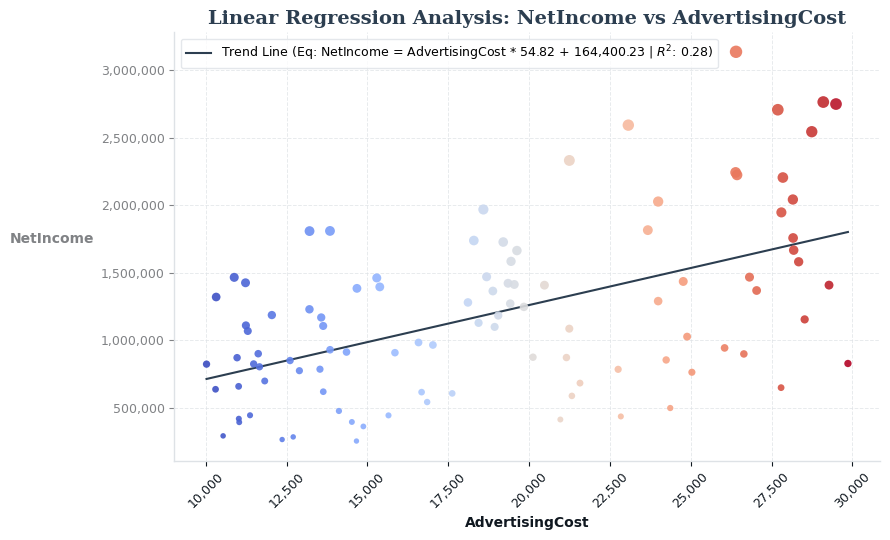

In [16]:
fig, _ = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                               variable_names.COST_ADVERTISING, variable_names.NET_INCOME)
plt.show()